# Genome PRD v1 — 04 Model evaluation

Evaluate train, validation, and out-of-time test data with the established Phase 5/PRD definitions, including calibration, test-quarter metrics, and the same diagnostic plots used in the Phase 5 baseline notebook.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, roc_curve
from xgboost import XGBClassifier

here = Path.cwd().resolve()
ROOT = next(path for path in (here, *here.parents) if (path / 'src/training/prd_config.py').is_file())
sys.path.insert(0, str(ROOT))
from src.training import prd_config
from src.training.modeling import evaluate_model, write_json

MAX_CURVE_ROWS = 2_000_000

model = XGBClassifier()
model.load_model(prd_config.PRD_ARTIFACT_PATH)
ratings = pd.read_parquet(prd_config.RATINGS_SOURCE_PATH, columns=['rating'])['rating'].to_numpy(dtype=np.float32, copy=False)

## Canonical split, calibration, and quarterly metrics

In [2]:
results = evaluate_model(
    model,
    prd_config.FEATURE_ARTIFACT_PATH,
    ratings,
    curve_sample_rows=MAX_CURVE_ROWS,
)
curve_samples = results.pop('curve_samples')
metric_table = pd.DataFrame(results['metrics']).T[['Rows', 'Prevalence', 'PR-AUC', 'ROC-AUC', 'Log Loss', 'Brier']]
display(metric_table)
display(pd.DataFrame(results['test_quarter_metrics']).T)
display(pd.DataFrame(results['test_calibration_bins']).T)
print('Test ECE (10 uniform bins):', results['test_calibration_ece_10_uniform_bins'])

,Rows,Prevalence,PR-AUC,ROC-AUC,Log Loss,Brier
train,17822773.0,0.498194,0.810687,0.821742,0.513867,0.172123
validation,1330716.0,0.519539,0.822578,0.819767,0.516197,0.172799
test,846774.0,0.501728,0.809925,0.820356,0.517775,0.173378


,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Brier
2014Q1,134320.0,0.530286,0.820049,0.828507,0.514417,0.172242
2014Q2,117973.0,0.512236,0.816483,0.815080,0.521169,0.174585
2014Q3,112771.0,0.529693,0.816499,0.825700,0.520001,0.174133
2014Q4,197824.0,0.500268,0.820598,0.810085,0.519509,0.174043
2015Q1,283886.0,0.473757,0.824421,0.794400,0.515862,0.172649


,rows,average_prediction,observed_prevalence,absolute_gap
0.0-0.1,83260.0,0.047679,0.039659,0.008020
0.1-0.2,72568.0,0.149635,0.141743,0.007892
0.2-0.3,71947.0,0.250097,0.241622,0.008475
0.3-0.4,73209.0,0.350382,0.335778,0.014603
0.4-0.5,77945.0,0.450778,0.425685,0.025093
0.5-0.6,84911.0,0.550759,0.522818,0.027941
0.6-0.7,93003.0,0.650648,0.617657,0.032990
0.7-0.8,99301.0,0.750426,0.715884,0.034542
0.8-0.9,109669.0,0.850817,0.812581,0.038236
0.9-1.0,80961.0,0.939056,0.914959,0.024097


Test ECE (10 uniform bins): 0.02348927749133359


## ROC and precision-recall curves

Curves use a deterministic subsample of at most 2M rows per split; the metric table above still uses the full partitions.

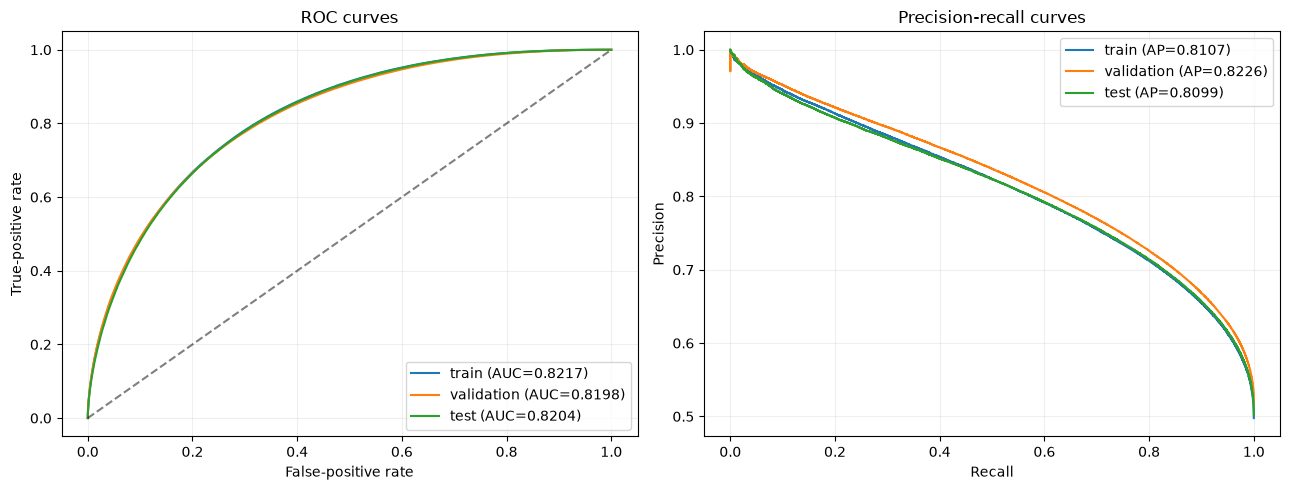

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split_name, (y_curve, p_curve) in curve_samples.items():
    fpr, tpr, _ = roc_curve(y_curve, p_curve)
    precision, recall, _ = precision_recall_curve(y_curve, p_curve)
    axes[0].plot(fpr, tpr, label=f"{split_name} (AUC={results['metrics'][split_name]['ROC-AUC']:.4f})")
    axes[1].plot(recall, precision, label=f"{split_name} (AP={results['metrics'][split_name]['PR-AUC']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set(xlabel='False-positive rate', ylabel='True-positive rate', title='ROC curves')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-recall curves')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Score distributions

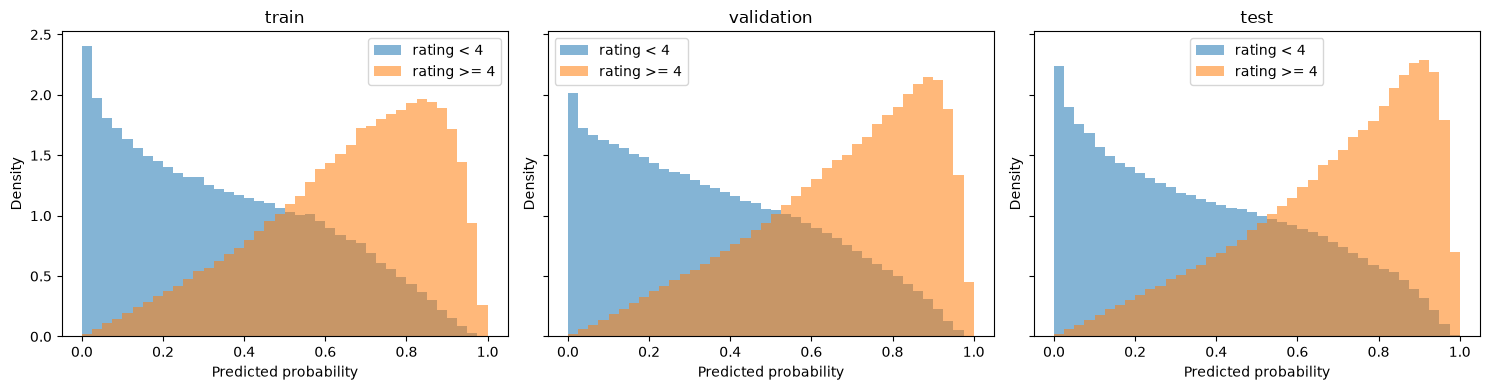

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
bins = np.linspace(0, 1, 41)
for ax, (split_name, (y_curve, p_curve)) in zip(axes, curve_samples.items()):
    ax.hist(p_curve[y_curve == 0], bins=bins, density=True, alpha=0.55, label='rating < 4')
    ax.hist(p_curve[y_curve == 1], bins=bins, density=True, alpha=0.55, label='rating >= 4')
    ax.set(title=split_name, xlabel='Predicted probability', ylabel='Density')
    ax.legend()
plt.tight_layout()
plt.show()

## Test calibration

Reliability curve from the equal-width probability bins already stored in the PRD results payload.

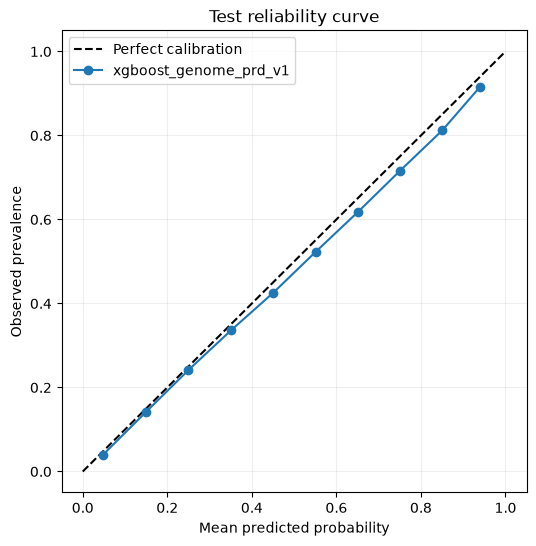

Test Brier score: 0.1733776181936264
Test ECE (10 uniform bins): 0.02348927749133359


In [5]:
calibration = pd.DataFrame(results['test_calibration_bins']).T
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(
    calibration['average_prediction'],
    calibration['observed_prevalence'],
    marker='o',
    label=prd_config.PRD_MODEL_NAME,
)
ax.set(
    xlabel='Mean predicted probability',
    ylabel='Observed prevalence',
    title='Test reliability curve',
)
ax.grid(alpha=0.2)
ax.legend()
plt.show()
print('Test Brier score:', results['metrics']['test']['Brier'])
print('Test ECE (10 uniform bins):', results['test_calibration_ece_10_uniform_bins'])

## Gain feature importance

,gain
feature,
genome_preference_margin,8434.924805
movie_mean_rating,4103.211914
user_target_genre_mean_rating,3948.826904
user_mean_rating,3811.644531
genome_user_positive_cosine,1110.785522
genome_nearest_liked_similarity,721.757385
user_rating_count,516.495972
user_rating_std_pop,490.389130
genome_top5_liked_similarity,464.775665


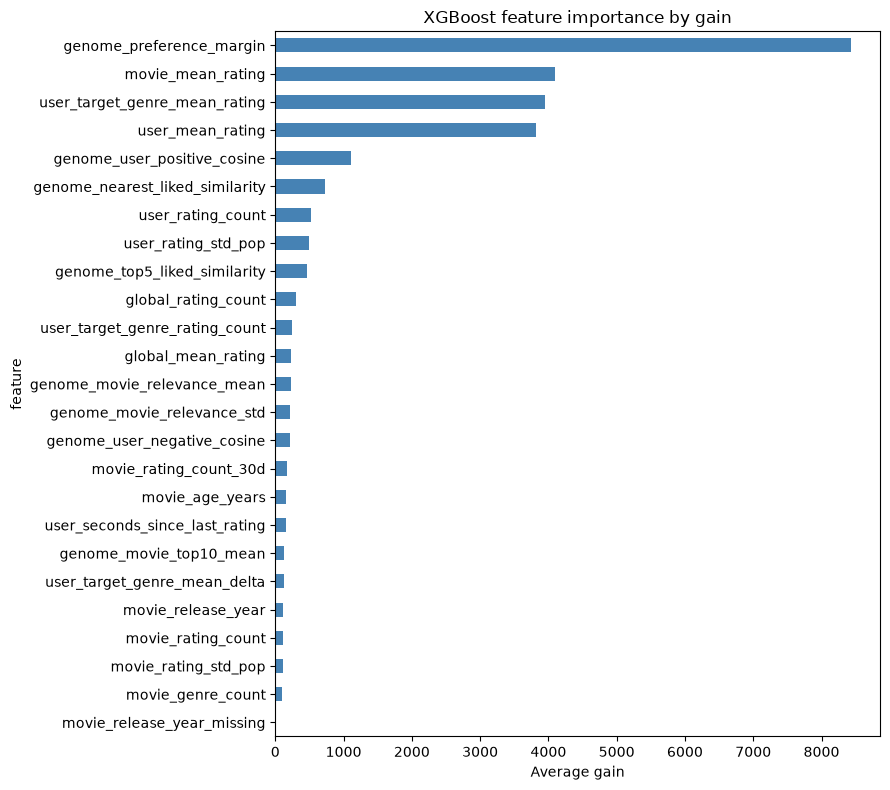

In [6]:
importance = (
    pd.DataFrame(results['gain_importance'])
    .set_index('feature')['gain']
    .sort_values(ascending=True)
)
display(importance.sort_values(ascending=False).to_frame())
ax = importance.plot.barh(
    figsize=(9, 8),
    color='steelblue',
    title='XGBoost feature importance by gain',
)
ax.set_xlabel('Average gain')
plt.tight_layout()
plt.show()

## Test-quarter metric trajectories

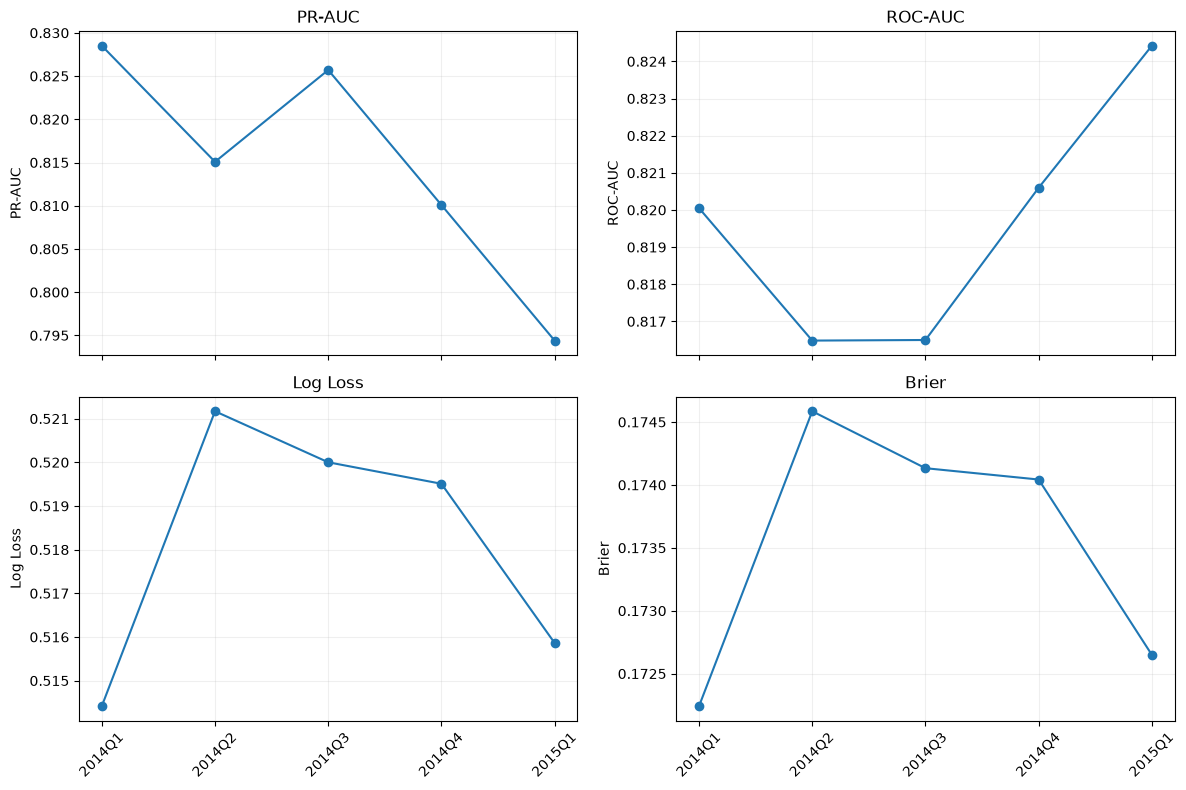

In [7]:
quarter_table = pd.DataFrame(results['test_quarter_metrics']).T.loc[
    list(prd_config.PRD_TEST_QUARTERS),
    ['PR-AUC', 'ROC-AUC', 'Log Loss', 'Brier'],
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, metric in zip(axes.ravel(), quarter_table.columns):
    ax.plot(quarter_table.index, quarter_table[metric], marker='o')
    ax.set(title=metric, ylabel=metric)
    ax.grid(alpha=0.2)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Save the compact canonical PRD results artifact

In [8]:
write_json(prd_config.PRD_RESULTS_PATH, results)
print('Saved:', prd_config.PRD_RESULTS_PATH.relative_to(ROOT))

Saved: models/prd/xgboost_genome_prd_v1.results.json
